In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split


In [10]:
df=pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

In [11]:
print(df.columns[:5])
print(df_test.columns[:5])

Index(['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3'], dtype='str')
Index(['pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4'], dtype='str')


In [12]:
X = df.drop("label", axis=1)
y = df["label"]

In [13]:
X = X.astype('float32') / 255.0

In [16]:
X = X.to_numpy()

In [17]:
X=X.reshape(-1,28,28,1)

In [18]:
y=to_categorical(y,num_classes=10)

In [19]:
y

array([[0., 1., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(42000, 10))

In [20]:
y.shape

(42000, 10)

In [21]:
X.shape

(42000, 28, 28, 1)

In [22]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
print(X_train.shape)
print(X_val.shape)

print(y_train.shape)
print(y_val.shape)

(33600, 28, 28, 1)
(8400, 28, 28, 1)
(33600, 10)
(8400, 10)


In [24]:
cnn = Sequential([

    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),

    MaxPooling2D(pool_size=(2,2)),

    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu'
    ),

    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(10, activation='softmax')

])

c:\Users\sindh\miniconda3\envs\ml_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [27]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [28]:
history = cnn.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.9126 - loss: 0.2801 - val_accuracy: 0.9777 - val_loss: 0.0683
Epoch 2/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.9706 - loss: 0.0987 - val_accuracy: 0.9854 - val_loss: 0.0476
Epoch 3/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.9789 - loss: 0.0686 - val_accuracy: 0.9881 - val_loss: 0.0382
Epoch 4/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.9825 - loss: 0.0575 - val_accuracy: 0.9902 - val_loss: 0.0347
Epoch 5/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.9854 - loss: 0.0477 - val_accuracy: 0.9899 - val_loss: 0.0326
Epoch 6/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accuracy: 0.9867 - loss: 0.0435 - val_accuracy: 0.9906 - val_loss: 0.0350
Epoch 7/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accuracy: 0.9886 - loss: 0.0355 - val_accuracy: 0.9905 - val_loss: 0.0330
Epoch 8/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accuracy: 0.9900 -

In [29]:
loss, accuracy = cnn.evaluate(X_val, y_val)

print("Validation Loss :", loss)
print("Validation Accuracy :", accuracy)

263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9899 - loss: 0.0326
Validation Loss : 0.03263070806860924
Validation Accuracy : 0.9898809790611267


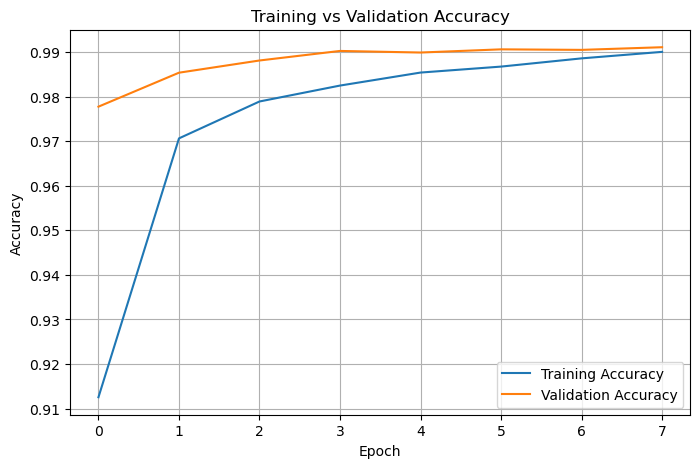

In [30]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()